In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re


In [38]:
# from datasets import load_dataset

# dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Books", split="full", trust_remote_code=True)

In [5]:
# first 1 million reviews
sample_dataset = dataset.shuffle(seed=42).select(range(1_000_000))

In [6]:
sample_dataset.to_csv("item_reviews_books.csv",header=True,index=False)

Creating CSV from Arrow format:   0%|          | 0/1000 [00:00<?, ?ba/s]

3301647092

In [ ]:
sample_dataset[0]

{'main_category': 'Books',
 'title': 'Outcast',
 'average_rating': 4.0,
 'rating_number': 3,
 'features': ['A breathtaking tale of love in the West--by the author of Autumnfire. Olivia Baron scandalizes the prudish matrons and rough cowboys of Elkhorn by practicing medicine. When a diptheria epidemic breaks out, she can finally prove her mettle to the townspeople--and to the handsome widower Gabe Danaker.'],
 'description': [],
 'price': '5.97',
 'images': {'hi_res': [None],
  'large': ['https://m.media-amazon.com/images/I/51VW3892J2L._SX288_BO1,204,203,200_.jpg'],
  'thumb': [None],
  'variant': ['MAIN']},
 'videos': {'title': [], 'url': [], 'user_id': []},
 'store': 'Emily Carmichael (Author)',
 'categories': ['Books', 'Literature & Fiction', 'Genre Fiction'],
 'details': '{"Publisher": "Grand Central Publishing (February 1, 1995)", "Language": "English", "Hardcover": "281 pages", "ISBN 10": "0446364118", "ISBN 13": "978-0446364119", "Item Weight": "6 ounces", "Dimensions": "4.5 x 1 

In [ ]:
sample_dataset_200 = dataset.shuffle(seed=42).select(range(200000))

Text(0, 0.5, 'Count')

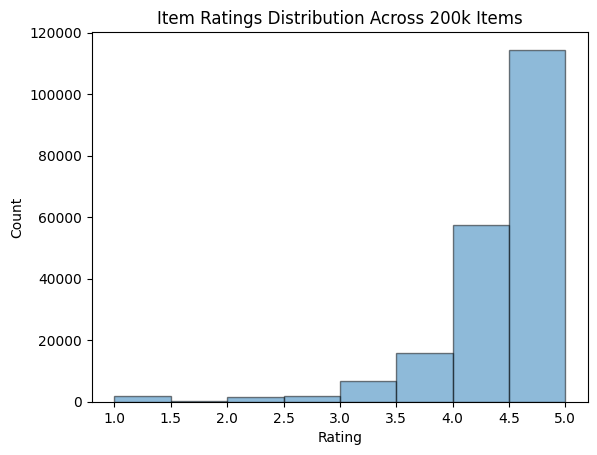

In [62]:
plt.hist(sample_dataset_200['average_rating'], bins=8, alpha=0.5, edgecolor='black')
plt.title('Item Ratings Distribution Across 200k Items')
plt.xlabel('Rating')
plt.ylabel('Count')

In [ ]:
sample_dataset['average_rating']!=0

True

In [37]:
def clean_price(value):
    if isinstance(value, str):
        match = re.search(r"\d+(\.\d+)?", value)
        return float(match.group()) if match else np.nan
    return np.nan

clean_prices = [clean_price(x) for x in sample_dataset_200['price']]
clean_prices = np.array(clean_prices, dtype=float)
clean_prices = clean_prices[~np.isnan(clean_prices)]

In [46]:
len(clean_prices)

161647

In [61]:
sample_dataset_200['price'][:20]

['5.97',
 '15.99',
 'from 9.99',
 '6.68',
 'None',
 '8.3',
 '50.76',
 '—',
 'None',
 'None',
 '28.0',
 'None',
 '—',
 '32.55',
 '6.99',
 'None',
 '14.99',
 '80.0',
 '0.0',
 '12.65']

Text(0, 0.5, 'Count')

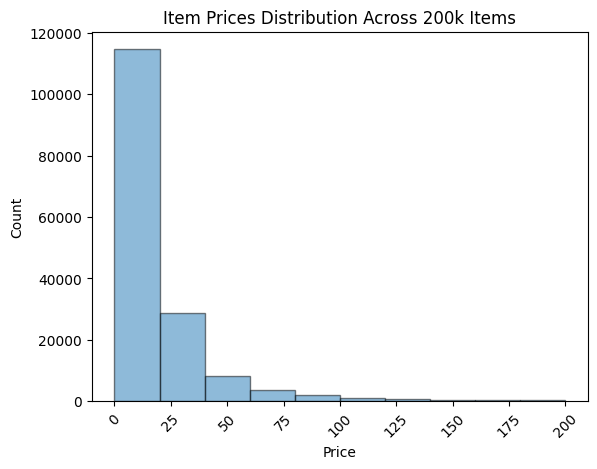

In [60]:
# bins = np.histogram_bin_edges(clean_prices, bins=8)
plt.hist(clean_prices[clean_prices<200], alpha=0.5, edgecolor='black')
plt.xticks(rotation=45)
plt.title('Item Prices Distribution Across 200k Items')
plt.xlabel('Price')
plt.ylabel('Count')

In [66]:
np.all(sample_dataset_200['bought_together']==None)

False

In [71]:
# for i in range(len(sample_dataset_200['bought_together'])):
#     if sample_dataset_200['bought_together'][i] != None:
#         print(sample_dataset_200['bought_together'][i])